# 05 — Qwen3-8B Legal Summarization Evaluation

This notebook evaluates the QLoRA adapter produced by notebook 04 on the held-out
document-level test sets created by notebook 03. It compares base Qwen3-8B with
the fine-tuned adapter on exactly the same cases.

Evaluation includes:

- restartable, deterministic chunk-summary generation;
- case-level reconstruction in `chunk_index` order;
- multi-reference ROUGE-1, ROUGE-2 and ROUGE-L;
- multi-reference BERTScore;
- legal-citation and number support against the source judgment;
- latency, throughput and peak GPU memory;
- paired bootstrap confidence intervals for QLoRA improvement.

**Important:** restart the kernel before running this notebook so notebook 04's
training model and optimizer no longer occupy GPU memory. Test references are
loaded only after generation and are never included in model prompts.



## 1. Environment setup



In [1]:
# Uncomment and run once if required, then restart the kernel.
%pip install -U --no-cache-dir "transformers==5.6.2" "peft>=0.20" \
    "accelerate>=1.14" "bitsandbytes>=0.46.1" "rouge-score>=0.1.2" \
    "bert-score>=0.3.13" pandas matplotlib seaborn tqdm python-dotenv packaging



  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 451.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 459.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.5 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24987 sha256=a5017ba369b2f03d0696daa8828fc2e3de81eb78abb19919dd3aa7b66fb8da19
  Stored in directory: /tmp/pip-ephem-wheel-cache-nv6j96_p/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3
  A

## 2. Configuration

The default evaluates 25 cases from each test partition. Set
`LEGAL_EVAL_CASE_LIMIT=0` before starting Jupyter for the complete benchmark.
Existing generation files are resumed automatically.



In [1]:
import os
from pathlib import Path

# Must be set before importing torch. Physical GPU 1 appears as cuda:0 inside Python.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", os.getenv("LEGAL_CUDA_VISIBLE_DEVICES", "1"))
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

PROJECT_ROOT = Path(os.getenv(
    "LEGALMIND_PROJECT_ROOT",
    "/data2/user_data/sg57092c/LLM_finetune",
)).expanduser()

MODEL_NAME = "Qwen/Qwen3-8B"
ADAPTER_DIR = PROJECT_ROOT / "models" / "qwen3_8b_legal_qlora" / "adapter"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "qwen3_8b_long_document"
TRAINING_SUMMARY = (
    PROJECT_ROOT / "artifacts" / "qwen3_8b_qlora_training" / "training_summary.json"
)
PREPROCESSING_REPORT = (
    PROJECT_ROOT / "artifacts" / "qwen3_8b_long_document_preprocessing"
    / "preprocessing_report.json"
)
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "qwen3_8b_model_evaluation"

PARTITIONS = ("test_in_abs", "test_in_ext_expert", "test_uk_abs")
CASE_LIMIT_PER_PARTITION = int(os.getenv("LEGAL_EVAL_CASE_LIMIT", "25"))
RUN_BASELINE = os.getenv("LEGAL_RUN_BASELINE", "1") == "1"
OVERWRITE_PREDICTIONS = os.getenv("LEGAL_OVERWRITE_PREDICTIONS", "0") == "1"
RANDOM_SEED = 42
MAX_NEW_TOKENS = int(os.getenv("LEGAL_MAX_NEW_TOKENS", "768"))
BERTSCORE_MODEL = os.getenv("LEGAL_BERTSCORE_MODEL", "roberta-large")
BERTSCORE_BATCH_SIZE = int(os.getenv("LEGAL_BERTSCORE_BATCH_SIZE", "8"))
BERTSCORE_SEGMENT_WORDS = int(os.getenv("LEGAL_BERTSCORE_SEGMENT_WORDS", "250"))
BOOTSTRAP_SAMPLES = 2000
ATTN_IMPLEMENTATION = os.getenv("LEGAL_ATTN_IMPLEMENTATION", "sdpa")

RUN_TAG = "full" if CASE_LIMIT_PER_PARTITION == 0 else f"sample_{CASE_LIMIT_PER_PARTITION}"
RUN_DIR = ARTIFACT_ROOT / RUN_TAG
PREDICTION_DIR = RUN_DIR / "predictions"
for directory in (RUN_DIR, PREDICTION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Project root  :", PROJECT_ROOT)
print("Adapter       :", ADAPTER_DIR)
print("Partitions    :", PARTITIONS)
print("Evaluation    :", "FULL" if CASE_LIMIT_PER_PARTITION == 0 else RUN_TAG)
print("Run baseline  :", RUN_BASELINE)
print("Visible GPU(s):", os.environ["CUDA_VISIBLE_DEVICES"])



Project root  : /data2/user_data/sg57092c/LLM_finetune
Adapter       : /data2/user_data/sg57092c/LLM_finetune/models/qwen3_8b_legal_qlora/adapter
Partitions    : ('test_in_abs', 'test_in_ext_expert', 'test_uk_abs')
Evaluation    : sample_25
Run baseline  : True
Visible GPU(s): 1


## 3. Imports, versions and reproducibility



In [2]:
import gc
import hashlib
import json
import math
import platform
import random
import re
import time
from collections import defaultdict
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import transformers
from bert_score import score as bert_score
from dotenv import load_dotenv
from packaging.version import Version
from peft import PeftConfig, PeftModel
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed

EXPECTED_TRANSFORMERS_VERSION = "5.6.2"
if transformers.__version__ != EXPECTED_TRANSFORMERS_VERSION:
    raise RuntimeError(
        f"Use transformers=={EXPECTED_TRANSFORMERS_VERSION}; found {transformers.__version__}."
    )
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required for this 4-bit evaluation notebook.")

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"

bnb_version = package_version("bitsandbytes")
if bnb_version == "not installed" or Version(bnb_version) < Version("0.46.1"):
    raise RuntimeError(f"bitsandbytes>=0.46.1 is required; found {bnb_version}.")

set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.backends.cuda.matmul.allow_tf32 = True

gpu = torch.cuda.get_device_properties(0)
USE_BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
free_bytes, total_bytes = torch.cuda.mem_get_info(0)

environment = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "peft": package_version("peft"),
    "bitsandbytes": bnb_version,
    "gpu": gpu.name,
    "free_gpu_gib": round(free_bytes / 1024**3, 2),
    "total_gpu_gib": round(total_bytes / 1024**3, 2),
    "compute_dtype": str(COMPUTE_DTYPE),
}
display(pd.DataFrame([environment]))
if free_bytes / 1024**3 < 25:
    raise RuntimeError("Less than 25 GiB GPU memory is free. Restart the kernel or choose a free GPU.")



,python,torch,transformers,peft,bitsandbytes,gpu,free_gpu_gib,total_gpu_gib,compute_dtype
0,3.12.3,2.5.1+cu121,5.6.2,0.20.0,0.50.2,NVIDIA H100 80GB HBM3,78.68,79.19,torch.bfloat16


## 4. Validate training and preprocessing artifacts



In [3]:
required_paths = {
    "adapter": ADAPTER_DIR,
    "training_summary": TRAINING_SUMMARY,
    "preprocessing_report": PREPROCESSING_REPORT,
}
for partition in PARTITIONS:
    required_paths[f"{partition}_chunks"] = PROCESSED_DIR / f"{partition}_chunks.jsonl"
    required_paths[f"{partition}_references"] = PROCESSED_DIR / f"{partition}_references.jsonl"

missing = [str(path) for path in required_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts:\n- " + "\n- ".join(missing))

with open(TRAINING_SUMMARY, encoding="utf-8") as file:
    training_summary = json.load(file)
with open(PREPROCESSING_REPORT, encoding="utf-8") as file:
    preprocessing_report = json.load(file)

peft_config = PeftConfig.from_pretrained(ADAPTER_DIR)
adapter_base_name = str(peft_config.base_model_name_or_path)
if adapter_base_name != MODEL_NAME:
    raise ValueError(f"Adapter expects {adapter_base_name}, not {MODEL_NAME}.")
if preprocessing_report["tokenizer"] != MODEL_NAME:
    raise ValueError("Notebook 03 tokenizer does not match the evaluation model.")

MAX_SEQUENCE_TOKENS = int(preprocessing_report["train_sequence_tokens"])
lineage = {
    "model": MODEL_NAME,
    "adapter": str(ADAPTER_DIR),
    "full_validation_loss": training_summary.get("full_validation_metrics", {}).get(
        "full_validation_loss"
    ),
    "best_checkpoint": training_summary.get("best_checkpoint"),
    "max_sequence_tokens": MAX_SEQUENCE_TOKENS,
    "training_examples": training_summary.get("train_examples"),
    "validation_examples": training_summary.get("validation_examples"),
    "semantic_match_rate": preprocessing_report.get("semantic_match_rate"),
}
display(pd.DataFrame([lineage]))



,model,adapter,full_validation_loss,best_checkpoint,max_sequence_tokens,training_examples,validation_examples,semantic_match_rate
0,Qwen/Qwen3-8B,/data2/user_data/sg57092c/LLM_finetune/models/...,1.063507,/data2/user_data/sg57092c/LLM_finetune/models/...,4096,15333,1730,0.959853


## 5. Load held-out chunks and references



In [4]:
def read_jsonl(path):
    records = []
    with open(path, encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as error:
                raise ValueError(f"Invalid JSON in {path}, line {line_number}") from error
    return records

def case_key(record):
    return f"{record['dataset']}::{record['case_id']}::{record['judgment_hash']}"

all_chunks = []
all_references = []
selection_rows = []

for partition in PARTITIONS:
    chunks = read_jsonl(required_paths[f"{partition}_chunks"])
    references = read_jsonl(required_paths[f"{partition}_references"])
    available_keys = sorted({case_key(record) for record in chunks})
    rng = random.Random(RANDOM_SEED + sum(ord(char) for char in partition))
    rng.shuffle(available_keys)
    selected_keys = set(
        available_keys if CASE_LIMIT_PER_PARTITION == 0
        else available_keys[:CASE_LIMIT_PER_PARTITION]
    )

    selected_chunks = [record for record in chunks if case_key(record) in selected_keys]
    selected_references = [
        record for record in references if case_key(record) in selected_keys
    ]
    reference_keys = {case_key(record) for record in selected_references}
    if selected_keys - reference_keys:
        raise ValueError(f"{partition} has selected cases without references.")

    for record in selected_chunks:
        record["case_key"] = case_key(record)
    for record in selected_references:
        record["case_key"] = case_key(record)
    all_chunks.extend(selected_chunks)
    all_references.extend(selected_references)
    selection_rows.append({
        "partition": partition,
        "available_cases": len(available_keys),
        "selected_cases": len(selected_keys),
        "selected_chunks": len(selected_chunks),
        "references": len(selected_references),
        "mean_chunks_per_case": round(len(selected_chunks) / len(selected_keys), 2),
    })

chunks_df = pd.DataFrame(all_chunks).sort_values(
    ["partition", "case_key", "chunk_index"]
).reset_index(drop=True)
references_df = pd.DataFrame(all_references)
display(pd.DataFrame(selection_rows))
print("Total generation requests per model:", len(chunks_df))

,partition,available_cases,selected_cases,selected_chunks,references,mean_chunks_per_case
0,test_in_abs,100,25,85,25,3.40
1,test_in_ext_expert,50,25,137,50,5.48
2,test_uk_abs,99,25,186,25,7.44


Total generation requests per model: 408


## 6. Leakage and prompt-integrity gates



In [ ]:
def collect_hashes(path):
    hashes = set()
    with open(path, encoding="utf-8") as file:
        for line in file:
            hashes.add(json.loads(line)["judgment_hash"])
    return hashes

training_hashes = collect_hashes(PROCESSED_DIR / "sft_train.jsonl")
validation_hashes = collect_hashes(PROCESSED_DIR / "sft_validation.jsonl")
test_hashes = set(chunks_df["judgment_hash"])

if test_hashes & training_hashes:
    raise ValueError("Test leakage: held-out judgments occur in the SFT training data.")
if test_hashes & validation_hashes:
    raise ValueError("Test leakage: held-out judgments occur in SFT validation data.")
if chunks_df["prompt"].str.contains("reference_summary", case=False, regex=False).any():
    raise ValueError("A prompt appears to expose reference-summary content.")
if chunks_df["chunk_id"].duplicated().any():
    raise ValueError("Duplicate chunk IDs detected.")

expected_chunk_counts = chunks_df.groupby("case_key")["total_chunks"].first()
actual_chunk_counts = chunks_df.groupby("case_key").size()
if not expected_chunk_counts.equals(actual_chunk_counts):
    raise ValueError("At least one selected case has missing inference chunks.")

print("PASS: held-out hashes, reference isolation, unique IDs and chunk coverage are valid.")

PASS: held-out hashes, reference isolation, unique IDs and chunk coverage are valid.


## 7. Load tokenizer and 4-bit base model



In [6]:
load_dotenv(PROJECT_ROOT / ".env")
hf_token = os.getenv("HF_TOKEN")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    token=hf_token or None,
    use_fast=True,
)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=hf_token or None,
    quantization_config=quantization_config,
    device_map={"": torch.cuda.current_device()},
    dtype=COMPUTE_DTYPE,
    attn_implementation=ATTN_IMPLEMENTATION,
    low_cpu_mem_usage=True,
)
base_model.eval()
base_model.config.use_cache = True
base_model.config.pad_token_id = tokenizer.pad_token_id
print("Loaded base model on:", base_model.device)
print(f"Model footprint: {base_model.get_memory_footprint() / 1024**3:.2f} GiB")



Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loaded base model on: cuda:0
Model footprint: 5.55 GiB


## 8. Restartable deterministic chunk generation



In [7]:
THINK_BLOCK = re.compile(r"^\s*<think>.*?</think>\s*", flags=re.DOTALL | re.IGNORECASE)

def clean_summary(text):
    text = THINK_BLOCK.sub("", text).strip()
    return re.sub(r"\n{3,}", "\n\n", text)

def load_existing_predictions(path, expected_model_label):
    if OVERWRITE_PREDICTIONS or not path.exists():
        return {}
    existing = {}
    for record in read_jsonl(path):
        if record.get("model_label") != expected_model_label:
            raise ValueError(f"Unexpected model label in {path}")
        existing[record["chunk_id"]] = record
    return existing

def generate_predictions(model, model_label, output_path):
    existing = load_existing_predictions(output_path, model_label)
    mode = "w" if OVERWRITE_PREDICTIONS else "a"
    if OVERWRITE_PREDICTIONS:
        existing = {}

    with open(output_path, mode, encoding="utf-8") as output_file:
        for row in tqdm(
            chunks_df.itertuples(index=False),
            total=len(chunks_df),
            desc=f"Generating {model_label}",
        ):
            if row.chunk_id in existing:
                continue

            encoded = tokenizer(
                row.prompt,
                add_special_tokens=False,
                return_tensors="pt",
            ).to(model.device)
            prompt_tokens = int(encoded["input_ids"].shape[1])
            available_tokens = MAX_SEQUENCE_TOKENS - prompt_tokens
            if available_tokens < 32:
                raise ValueError(f"Insufficient output budget for {row.chunk_id}")
            output_budget = min(MAX_NEW_TOKENS, available_tokens)

            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            started = time.perf_counter()
            with torch.inference_mode():
                generated = model.generate(
                    **encoded,
                    max_new_tokens=output_budget,
                    do_sample=False,
                    repetition_penalty=1.05,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )
            torch.cuda.synchronize()
            latency = time.perf_counter() - started
            generated_ids = generated[0, prompt_tokens:]
            prediction = clean_summary(tokenizer.decode(
                generated_ids,
                skip_special_tokens=True,
            ))

            record = {
                "model_label": model_label,
                "partition": row.partition,
                "case_key": row.case_key,
                "case_id": row.case_id,
                "dataset": row.dataset,
                "judgment_hash": row.judgment_hash,
                "chunk_id": row.chunk_id,
                "chunk_index": int(row.chunk_index),
                "total_chunks": int(row.total_chunks),
                "prompt_tokens": prompt_tokens,
                "generated_tokens": int(generated_ids.numel()),
                "latency_seconds": float(latency),
                "peak_gpu_memory_gib": float(torch.cuda.max_memory_allocated() / 1024**3),
                "prediction": prediction,
            }
            output_file.write(json.dumps(record, ensure_ascii=False) + "\n")
            output_file.flush()
            existing[row.chunk_id] = record

    predictions = list(existing.values())
    required_ids = set(chunks_df["chunk_id"])
    available_ids = {record["chunk_id"] for record in predictions}
    if required_ids - available_ids:
        raise RuntimeError(f"{model_label} generation is incomplete.")
    return [record for record in predictions if record["chunk_id"] in required_ids]



## 9. Generate the base-model benchmark

This is the control condition. It uses the same prompts, decoding parameters and
selected cases as the adapter model.



In [8]:
prediction_sets = {}
if RUN_BASELINE:
    base_path = PREDICTION_DIR / "base_qwen3_8b_chunk_predictions.jsonl"
    prediction_sets["base"] = generate_predictions(base_model, "base", base_path)
    print("Saved/resumed:", base_path)
else:
    print("Base-model benchmark skipped because LEGAL_RUN_BASELINE=0.")



Generating base:   0%|          | 0/408 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved/resumed: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_model_evaluation/sample_25/predictions/base_qwen3_8b_chunk_predictions.jsonl


## 10. Attach the QLoRA adapter and generate fine-tuned predictions



In [9]:
adapter_model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
    is_trainable=False,
)
adapter_model.eval()
adapter_model.config.use_cache = True

adapter_path = PREDICTION_DIR / "qwen3_8b_qlora_chunk_predictions.jsonl"
prediction_sets["qlora"] = generate_predictions(adapter_model, "qlora", adapter_path)
print("Saved/resumed:", adapter_path)

Generating qlora:   0%|          | 0/408 [00:00<?, ?it/s]

Saved/resumed: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_model_evaluation/sample_25/predictions/qwen3_8b_qlora_chunk_predictions.jsonl


In [9]:
prediction_sets = {}

required_chunk_ids = set(chunks_df["chunk_id"])

def load_saved_predictions(path, model_label):
    if not path.exists():
        print(f"{model_label} predictions not found:", path)
        return

    records = read_jsonl(path)

    # Remove duplicates and retain only currently selected chunks
    records_by_id = {
        record["chunk_id"]: record
        for record in records
        if record["chunk_id"] in required_chunk_ids
    }

    missing_ids = required_chunk_ids - set(records_by_id)

    if missing_ids:
        raise ValueError(
            f"{model_label}: {len(missing_ids)} predictions are missing. "
            "Resume generation for this model."
        )

    prediction_sets[model_label] = list(records_by_id.values())
    print(f"Loaded {len(records_by_id)} saved {model_label} predictions.")


base_path = PREDICTION_DIR / "base_qwen3_8b_chunk_predictions.jsonl"
adapter_path = PREDICTION_DIR / "qwen3_8b_qlora_chunk_predictions.jsonl"

# Load whichever prediction files already exist
load_saved_predictions(base_path, "base")
load_saved_predictions(adapter_path, "qlora")

if not prediction_sets:
    raise FileNotFoundError("No completed prediction files were found.")

Loaded 408 saved base predictions.
Loaded 408 saved qlora predictions.


## 11. Reconstruct case-level summaries



In [10]:
source_by_chunk = chunks_df.set_index("chunk_id")["input_text"].to_dict()
case_rows = []

for model_label, records in prediction_sets.items():
    prediction_df = pd.DataFrame(records).sort_values(
        ["partition", "case_key", "chunk_index"]
    )
    for (partition, key), group in prediction_df.groupby(["partition", "case_key"]):
        group = group.sort_values("chunk_index")
        case_rows.append({
            "model_label": model_label,
            "partition": partition,
            "case_key": key,
            "case_id": group.iloc[0]["case_id"],
            "dataset": group.iloc[0]["dataset"],
            "prediction": "\n".join(group["prediction"].tolist()).strip(),
            "source_text": "\n".join(
                source_by_chunk[chunk_id] for chunk_id in group["chunk_id"]
            ),
            "chunks": len(group),
            "generated_tokens": int(group["generated_tokens"].sum()),
            "latency_seconds": float(group["latency_seconds"].sum()),
            "peak_gpu_memory_gib": float(group["peak_gpu_memory_gib"].max()),
        })

case_predictions_df = pd.DataFrame(case_rows)
reference_groups = (
    references_df.groupby(["partition", "case_key"])["reference_summary"]
    .apply(list)
    .to_dict()
)
prediction_reference_keys = set(zip(
    case_predictions_df["partition"],
    case_predictions_df["case_key"],
))

missing_reference_keys = prediction_reference_keys - set(reference_groups)

if missing_reference_keys:
    raise ValueError(
        f"{len(missing_reference_keys)} case predictions have no reference: "
        f"{sorted(missing_reference_keys)[:3]}"
    )
display(case_predictions_df.groupby(["model_label", "partition"]).agg(
    cases=("case_key", "nunique"),
    chunks=("chunks", "sum"),
    generated_tokens=("generated_tokens", "sum"),
    latency_minutes=("latency_seconds", lambda values: values.sum() / 60),
).reset_index().round(2))



,model_label,partition,cases,chunks,generated_tokens,latency_minutes
0,base,test_in_abs,25,85,30707,15.21
1,base,test_in_ext_expert,25,137,56082,30.03
2,base,test_uk_abs,25,186,72745,37.21
3,qlora,test_in_abs,25,85,50992,44.60
4,qlora,test_in_ext_expert,25,137,80850,71.12
5,qlora,test_uk_abs,25,186,133297,117.44


## 12. Multi-reference ROUGE and source-support proxies

For IN-Ext, which has multiple expert references, each metric uses the best
matching reference for that case. Citation and number support are measured
against the source judgment, not against the summary. These support rates are
useful hallucination proxies, but they are not substitutes for expert legal review.



In [11]:
rouge = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True,
)
LEGAL_CITATION_PATTERN = re.compile(
    r"\b(?:article|section|sections|rule|order)\s+\d+[A-Za-z]?"
    r"(?:\s*\([^)]{1,20}\))*|\b[A-Z][A-Za-z&.' -]{2,60}\s+Act(?:,?\s+\d{4})?",
    flags=re.IGNORECASE,
)
NUMBER_PATTERN = re.compile(r"\b\d+(?:\.\d+)?\b")

def normalized_items(pattern, text):
    return {
        re.sub(r"\s+", " ", match.group(0).lower()).strip()
        for match in pattern.finditer(text)
    }

def source_support(pattern, prediction, source):
    predicted = normalized_items(pattern, prediction)
    if not predicted:
        return 1.0, 0
    normalized_source = re.sub(r"\s+", " ", source.lower())
    supported = sum(item in normalized_source for item in predicted)
    return supported / len(predicted), len(predicted)

pair_rows = []
for row in tqdm(case_predictions_df.itertuples(index=False), total=len(case_predictions_df)):
    references = reference_groups[(row.partition, row.case_key)]
    citation_support, citation_count = source_support(
        LEGAL_CITATION_PATTERN, row.prediction, row.source_text
    )
    number_support, number_count = source_support(
        NUMBER_PATTERN, row.prediction, row.source_text
    )
    for reference_index, reference in enumerate(references):
        scores = rouge.score(reference, row.prediction)
        pair_rows.append({
            "model_label": row.model_label,
            "partition": row.partition,
            "case_key": row.case_key,
            "reference_index": reference_index,
            "prediction": row.prediction,
            "reference": reference,
            "rouge1_f1": scores["rouge1"].fmeasure,
            "rouge2_f1": scores["rouge2"].fmeasure,
            "rougeL_f1": scores["rougeL"].fmeasure,
            "citation_source_support": citation_support,
            "predicted_citation_count": citation_count,
            "number_source_support": number_support,
            "predicted_number_count": number_count,
            "latency_seconds": row.latency_seconds,
            "generated_tokens": row.generated_tokens,
            "peak_gpu_memory_gib": row.peak_gpu_memory_gib,
        })

pair_metrics_df = pd.DataFrame(pair_rows)
print("Prediction-reference pairs:", len(pair_metrics_df))



  0%|          | 0/150 [00:00<?, ?it/s]

Prediction-reference pairs: 200


## 13. BERTScore

Long prediction/reference pairs are divided into balanced, position-preserving
segments so the complete case summary is scored within the encoder's token window.
Segment scores are averaged per reference; then the strongest expert-reference
match is retained per case.



In [12]:
def balanced_word_segments(text, segment_count):
    words = text.split()
    if not words:
        return [""] * segment_count
    boundaries = np.linspace(0, len(words), segment_count + 1, dtype=int)
    return [
        " ".join(words[boundaries[index]:boundaries[index + 1]])
        for index in range(segment_count)
    ]

segment_rows = []
for pair_index, row in pair_metrics_df.iterrows():
    prediction_words = len(row["prediction"].split())
    reference_words = len(row["reference"].split())
    segment_count = max(
        1,
        math.ceil(prediction_words / BERTSCORE_SEGMENT_WORDS),
        math.ceil(reference_words / BERTSCORE_SEGMENT_WORDS),
    )
    prediction_segments = balanced_word_segments(row["prediction"], segment_count)
    reference_segments = balanced_word_segments(row["reference"], segment_count)
    for segment_index, (prediction_segment, reference_segment) in enumerate(
        zip(prediction_segments, reference_segments)
    ):
        segment_rows.append({
            "pair_index": pair_index,
            "segment_index": segment_index,
            "prediction": prediction_segment,
            "reference": reference_segment,
        })

segment_df = pd.DataFrame(segment_rows)
precision, recall, f1 = bert_score(
    segment_df["prediction"].tolist(),
    segment_df["reference"].tolist(),
    model_type=BERTSCORE_MODEL,
    device="cuda:0",
    batch_size=BERTSCORE_BATCH_SIZE,
    verbose=True,
    rescale_with_baseline=False,
)
segment_df["bertscore_precision"] = precision.cpu().numpy()
segment_df["bertscore_recall"] = recall.cpu().numpy()
segment_df["bertscore_f1"] = f1.cpu().numpy()
pair_bert_scores = segment_df.groupby("pair_index")[[
    "bertscore_precision", "bertscore_recall", "bertscore_f1"
]].mean()
pair_metrics_df = pair_metrics_df.join(pair_bert_scores)
print("BERTScore segments:", len(segment_df))

case_metric_rows = []
for (model_label, partition, key), group in pair_metrics_df.groupby(
    ["model_label", "partition", "case_key"]
):
    best_bert = group.loc[group["bertscore_f1"].idxmax()]
    first = group.iloc[0]
    case_metric_rows.append({
        "model_label": model_label,
        "partition": partition,
        "case_key": key,
        "rouge1_f1": group["rouge1_f1"].max(),
        "rouge2_f1": group["rouge2_f1"].max(),
        "rougeL_f1": group["rougeL_f1"].max(),
        "bertscore_precision": best_bert["bertscore_precision"],
        "bertscore_recall": best_bert["bertscore_recall"],
        "bertscore_f1": best_bert["bertscore_f1"],
        "citation_source_support": first["citation_source_support"],
        "predicted_citation_count": first["predicted_citation_count"],
        "number_source_support": first["number_source_support"],
        "predicted_number_count": first["predicted_number_count"],
        "latency_seconds": first["latency_seconds"],
        "generated_tokens": first["generated_tokens"],
        "peak_gpu_memory_gib": first["peak_gpu_memory_gib"],
    })

case_metrics_df = pd.DataFrame(case_metric_rows)
case_metrics_df["tokens_per_second"] = (
    case_metrics_df["generated_tokens"] / case_metrics_df["latency_seconds"]
)
case_metrics_df.to_csv(RUN_DIR / "case_level_metrics.csv", index=False)
pair_metrics_df.drop(columns=["prediction", "reference"]).to_csv(
    RUN_DIR / "prediction_reference_metrics.csv", index=False
)
print("Saved case-level metrics.")



config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/397 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/235 [00:00<?, ?it/s]

done in 8.65 seconds, 217.39 sentences/sec
BERTScore segments: 1880
Saved case-level metrics.


## 14. Aggregate results and base-vs-QLoRA comparison



In [13]:
metric_columns = [
    "rouge1_f1", "rouge2_f1", "rougeL_f1", "bertscore_f1",
    "citation_source_support", "number_source_support", "tokens_per_second",
    "peak_gpu_memory_gib",
]

partition_summary = (
    case_metrics_df.groupby(["model_label", "partition"])[metric_columns]
    .mean()
    .reset_index()
)
overall_summary = (
    case_metrics_df.groupby("model_label")[metric_columns]
    .mean()
    .reset_index()
    .assign(partition="ALL")
)
summary_df = pd.concat([partition_summary, overall_summary], ignore_index=True)
summary_df.to_csv(RUN_DIR / "evaluation_summary.csv", index=False)
display(summary_df.round(4))

if {"base", "qlora"} <= set(case_metrics_df["model_label"]):
    paired = case_metrics_df.pivot(
        index=["partition", "case_key"],
        columns="model_label",
        values=["rouge1_f1", "rouge2_f1", "rougeL_f1", "bertscore_f1"],
    ).dropna()
    improvement_rows = []
    rng = np.random.default_rng(RANDOM_SEED)
    for metric in ("rouge1_f1", "rouge2_f1", "rougeL_f1", "bertscore_f1"):
        differences = (
            paired[(metric, "qlora")].to_numpy()
            - paired[(metric, "base")].to_numpy()
        )
        bootstrap_means = np.asarray([
            rng.choice(differences, size=len(differences), replace=True).mean()
            for _ in range(BOOTSTRAP_SAMPLES)
        ])
        improvement_rows.append({
            "metric": metric,
            "paired_cases": len(differences),
            "mean_qlora_minus_base": differences.mean(),
            "ci95_low": np.quantile(bootstrap_means, 0.025),
            "ci95_high": np.quantile(bootstrap_means, 0.975),
            "qlora_win_rate": (differences > 0).mean(),
        })
    improvement_df = pd.DataFrame(improvement_rows)
    improvement_df.to_csv(RUN_DIR / "paired_improvements.csv", index=False)
    display(improvement_df.round(4))
else:
    improvement_df = pd.DataFrame()
    print("Run the baseline to calculate paired improvements.")



,model_label,partition,rouge1_f1,rouge2_f1,rougeL_f1,bertscore_f1,citation_source_support,number_source_support,tokens_per_second,peak_gpu_memory_gib
0,base,test_in_abs,0.5365,0.2431,0.2476,0.8431,0.5357,0.9926,33.2161,6.3899
1,base,test_in_ext_expert,0.5981,0.2613,0.2479,0.8333,0.3214,0.9668,31.1080,6.3939
2,base,test_uk_abs,0.5142,0.2275,0.2165,0.8379,0.5554,1.0000,32.9491,6.4005
3,qlora,test_in_abs,0.5891,0.3777,0.3364,0.8430,0.8192,0.8959,19.0934,6.7535
4,qlora,test_in_ext_expert,0.5979,0.3929,0.3525,0.8263,0.6330,0.8036,18.9483,6.7594
5,qlora,test_uk_abs,0.4051,0.2054,0.1922,0.8156,0.8912,0.8500,18.9222,6.7694
6,base,ALL,0.5496,0.2440,0.2373,0.8381,0.4709,0.9865,32.4244,6.3948
7,qlora,ALL,0.5307,0.3254,0.2937,0.8283,0.7811,0.8499,18.9880,6.7608


,metric,paired_cases,mean_qlora_minus_base,ci95_low,ci95_high,qlora_win_rate
0,rouge1_f1,75,-0.0189,-0.0483,0.0085,0.4400
1,rouge2_f1,75,0.0814,0.0540,0.1075,0.6800
2,rougeL_f1,75,0.0564,0.0356,0.0770,0.6667
3,bertscore_f1,75,-0.0097,-0.0140,-0.0057,0.3467


## 15. Visual comparison



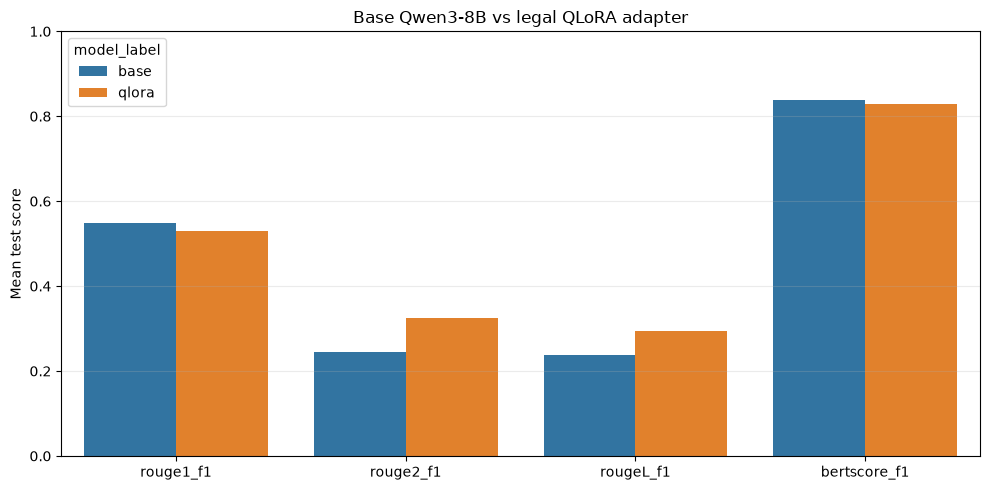

Saved: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_model_evaluation/sample_25/base_vs_qlora_metrics.png


In [14]:
plot_metrics = ["rouge1_f1", "rouge2_f1", "rougeL_f1", "bertscore_f1"]
plot_data = overall_summary.melt(
    id_vars=["model_label", "partition"],
    value_vars=plot_metrics,
    var_name="metric",
    value_name="score",
)

fig, axis = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_data, x="metric", y="score", hue="model_label", ax=axis)
axis.set_ylim(0, 1)
axis.set_title("Base Qwen3-8B vs legal QLoRA adapter")
axis.set_xlabel("")
axis.set_ylabel("Mean test score")
axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
figure_path = RUN_DIR / "base_vs_qlora_metrics.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)



## 16. Qualitative error analysis



In [15]:
reference_lookup = {
    (partition, key): summaries[0]
    for (partition, key), summaries in reference_groups.items()
}
comparison = case_predictions_df.pivot(
    index=["partition", "case_key"],
    columns="model_label",
    values="prediction",
).reset_index()
comparison["reference"] = comparison.apply(
    lambda row: reference_lookup[(row["partition"], row["case_key"])], axis=1
)

for row in comparison.head(3).itertuples(index=False):
    print("=" * 100)
    print("PARTITION:", row.partition, "CASE:", row.case_key)
    if hasattr(row, "base"):
        print("\nBASE:\n", row.base[:1800])
    print("\nQLORA:\n", row.qlora[:1800])
    print("\nREFERENCE:\n", row.reference[:1800])



PARTITION: test_in_abs CASE: IN-Abs::1181::a52eaf19e0dd9e4661e811cfe5a9a85ec4dd3077e6083759525b406c791f7db2

BASE:
 The appellants, displaced persons from West Pakistan, were granted quasi-permanent allotments of land in the villages of Raikot and Humbran in Ludhiana District in 1949. The appellants sought consolidation of their father's land in Humbran with their land in Raikot, but the application was rejected due to lack of available land in Raikot. Subsequently, the Additional Custodian for the State of Punjab, acting suo motu, canceled the appellants' allotment in Raikot and substituted it with land in Karodian, following the cancellation of allotments of 14 other persons. 

The 14 allottees of Karodian challenged the cancellation, leading to the restoration of their land by the Deputy Custodian General in 1954. This resulted in the automatic cancellation of the appellants' allotment in Karodian. The appellants then applied for a review of the cancellation of their Raikot allotmen

## 17. Save reproducibility report



In [ ]:
config_payload = {
    "model": MODEL_NAME,
    "adapter": str(ADAPTER_DIR),
    "partitions": list(PARTITIONS),
    "case_limit_per_partition": CASE_LIMIT_PER_PARTITION,
    "run_baseline": RUN_BASELINE,
    "random_seed": RANDOM_SEED,
    "max_new_tokens": MAX_NEW_TOKENS,
    "decoding": "greedy",
    "repetition_penalty": 1.05,
    "bertscore_model": BERTSCORE_MODEL,
    "bertscore_segment_words": BERTSCORE_SEGMENT_WORDS,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "environment": environment,
    "training_lineage": lineage,
}
config_text = json.dumps(config_payload, sort_keys=True, default=str)
config_payload["configuration_sha256"] = hashlib.sha256(config_text.encode()).hexdigest()

with open(RUN_DIR / "evaluation_config.json", "w", encoding="utf-8") as file:
    json.dump(config_payload, file, indent=2, default=str)

print("Evaluation artifacts:", RUN_DIR)
for path in sorted(RUN_DIR.rglob("*")):
    if path.is_file():
        print(f"- {path.relative_to(RUN_DIR)} ({path.stat().st_size / 1024**2:.2f} MiB)")

Evaluation artifacts: /data2/user_data/sg57092c/LLM_finetune/artifacts/qwen3_8b_model_evaluation/sample_25
- base_vs_qlora_metrics.png (0.05 MiB)
- case_level_metrics.csv (0.04 MiB)
- evaluation_config.json (0.00 MiB)
- evaluation_summary.csv (0.00 MiB)
- paired_improvements.csv (0.00 MiB)
- prediction_reference_metrics.csv (0.05 MiB)
- predictions/base_qwen3_8b_chunk_predictions.jsonl (0.95 MiB)
- predictions/qwen3_8b_qlora_chunk_predictions.jsonl (1.31 MiB)


## 18. Interpretation and handoff

Treat QLoRA as an improvement only when it beats the base model on the same
held-out cases, preferably with a positive paired 95% bootstrap interval.
ROUGE and BERTScore measure reference similarity; citation/number source support
provide limited grounding checks. They do not prove complete legal factuality.

The next project stage can build the production retrieval layer:
`06_hybrid_retrieval_and_reranking.ipynb`, using dense embeddings, BM25, reciprocal
rank fusion, a cross-encoder reranker, metadata filters and retrieval evaluation.
